
# <span style="color:rgb(213,80,0)">Adaptive Beamforming: Part I</span>

In [1]:
lambda = 3e-2;
M = 12;
position = (0:M-1).' * lambda/2;
steering_vector = @(theta) ...
    exp(-1j*2*pi/lambda * position * sind(theta));
SNR = 0;
INR = 20;
K = 5e3;%snapshots

## MVDR Beamformer

If no reference signal is available but the direction of arrival is known, an adaptive filter can enhance the signal from that direction while suppressing signals from interference directions.


Assume the signal model is


$$x(n)=As(n)+n$$

The received signal is a mixture of signals from multiple directions, including the desired signal and interference. We therefore seek a beamformer that extracts the signal arriving from the desired direction.


 $y(n)=w^H x(n)=w^H \lbrace As(n)+n\rbrace$ . The output can be decomposed into the desired\-signal and interference components:


$$\begin{array}{l} y(n)=w^H As(n)+w^H n\\ =w^H a(\theta_0 )s_0 (n)+w^H (\sum_{i=1}^k a(\theta_i )s_i (n))+w^H n \end{array}$$

First, the desired signal should pass through without distortion, which gives the constraint


 $w^H a(\theta_0 )=1$ . This means that the beam should be steered toward the direction of arrival.


We also want to minimize the output power of interference and noise. The signal output power (for a complex baseband signal, power equals the variance) can be written as


 $E[|y(n)|^2 ]=E[w^H x(n)x^H (n)w]=w^H R_{xx} w$ . Hence, the optimization problem is


$$\left\lbrace \begin{array}{l} \min_w w^H R_{xx} w\\ s.t.w^H a(\theta_0 )=1 \end{array}\right.$$

Using the method of Lagrange multipliers,


$$J(w)=w^H R_{xx} w+\lambda (w^H a(\theta_0 )-1)+\lambda^* (w^H a(\theta_0 )-1)^*$$

take the Wirtinger derivative:


 $\frac{\partial J}{\partial w^* }=R_{xx} w+\lambda a(\theta_0 )=0$ Thus, $w=-\lambda R_{xx}^{-1} a(\theta_0 )$ . Applying the equality constraint gives $\lambda =-\frac{1}{a^H (\theta_0 )R_{xx}^{-1} a(\theta_0 )}$ . Substituting this result back into the original expression yields the optimal weights:


$$w_{opt} =\frac{R_{xx}^{-1} a(\theta_0 )}{a^H (\theta_0 )R_{xx}^{-1} a(\theta_0 )}$$

In [2]:
s1 = wgn(1,K,SNR); % desired signal
interf1 = wgn(1,K,INR);
interf2 = wgn(1,K,INR);
noise = wgn(M,K,0);
% rn = (randn(1,K)+1j*randn(1,K))/sqrt(2);
% interf1 = (randn(1,K)+1j*randn(1,K))/sqrt(2);
% interf2 = (randn(1,K)+1j*randn(1,K))/sqrt(2);
% noise = (randn(M,K)+1j*randn(M,K))/sqrt(2);

theta = [0,-20,30];%three directions of arrival
S = [s1;interf1;interf2];
A = steering_vector(theta);
X = A*S+noise;
Rxx = X*X'/K;
a_theta0 = steering_vector(0);
w_unnormalized = Rxx \ a_theta0;
w_opt = w_unnormalized / (a_theta0' * w_unnormalized);

mvdr_inner_product = w_opt' * A;
disp('MVDR: w_opt^H * a(theta)');

MVDR: w_opt^H * a(theta)


In [3]:
disp(table(theta(:), mvdr_inner_product(:), ...
    abs(mvdr_inner_product(:)), ...
    'VariableNames', {'Theta_deg', 'InnerProduct', 'Magnitude'}));

    Theta_deg         InnerProduct         Magnitude
    _________    ______________________    _________

         0                1+1.7347e-18i            1
       -20        0.0012257-1.3764e-05i    0.0012258
        30       -0.0028469+6.8803e-05i    0.0028477



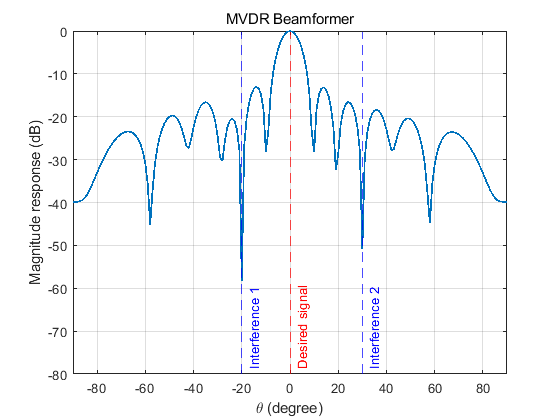

In [4]:
theta_plot = -90:1:90;
D_plot = steering_vector(theta_plot);     % M×Ntheta
P_LS_0 = w_opt'*D_plot;
BP_LS_0 = 20*log10( ...
    abs(P_LS_0)/max(abs(P_LS_0)) + eps);
figure;
h_bp = plot(theta_plot, BP_LS_0, 'LineWidth', 1.3);
grid on;
xlim([-90 90]);
ylim([-80 0]);
hold on;
h_desired = xline(theta(1), 'r--', 'Desired signal', ...
    'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
h_interf = gobjects(1, numel(theta)-1);
for ii = 2:numel(theta)
    h_interf(ii-1) = xline(theta(ii), 'b--', ...
        sprintf('Interference %d', ii-1), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title('MVDR Beamformer');

In [5]:
% legend([h_bp h_desired h_interf(1)], ...
%     {'MVDR pattern', 'Desired direction', 'Interference direction'}, ...
%     'Location', 'best');

## LCMV Beamformer

A Capon beamformer can enforce a response in only one direction at a time. In many cases, however, there are multiple desired and interference directions, so the MVDR constraints can be modified. For k desired\-signal directions and m interference directions, we obtain


$$\left\lbrace \begin{array}{l} a^H (\theta_i )w=1,i=1,2,...,k;\\ a^H (\theta_i )w=0,i=1,2,...,m \end{array}\right.$$

Combining the steering vectors into matrix form gives


$$\left\lbrace \begin{array}{l} \min_w w^H R_{xx} w\\ s.t.C^H w=f \end{array}\right.$$

Again applying the method of Lagrange multipliers, introduce the complex Lagrange\-multiplier vector


 $J(w)=w^H R_{xx} w-{{\lambda }}^H (C^H w-f)-(C^H w-f)^H {\lambda }=w^H R_{xx} w-{{\lambda }}^H (C^H w-f)-{{\lambda }}^T (C^T w^* -f^* )$ , and let $\frac{\partial J}{\partial w^* }=R_{xx} w-{{\lambda }}^T C^T =0$


This gives $w=R_{xx}^{-1} C{\lambda }$ . Substituting the constraint yields


 $f=C^H R_{xx}^{-1} C{\lambda }$ , and therefore ${\lambda }=(C^H R_{xx}^{-1} C)^{-1} f$


The optimal weights are finally $w=R_{xx}^{-1} C(C^H R_{xx}^{-1} C)^{-1} f$


In [6]:
s1 = wgn(1,K,SNR); % desired signal1
s2 = wgn(1,K,SNR); % desired signal2
interf1 = wgn(1,K,INR);
interf2 = wgn(1,K,INR);
noise = wgn(M,K,0);
theta = [0,20,-20,30];%four directions of arrival
S = [s1;s2;interf1;interf2];
A = steering_vector(theta);
X = A*S+noise;
Rxx = X*X'/K;

C = A;
f = [1;1;0;0];
% C = A(:,1:2);
% f = [1;1];

G = Rxx \ C;
w_opt = G * ((C' * G) \ f);

lcmv_inner_product = w_opt' * A;
disp('LCMV: w_opt^H * a(theta)');

LCMV: w_opt^H * a(theta)


In [7]:
disp(table(theta(:), lcmv_inner_product(:), ...
    abs(lcmv_inner_product(:)), ...
    'VariableNames', {'Theta_deg', 'InnerProduct', 'Magnitude'}));

    Theta_deg         InnerProduct          Magnitude 
    _________    _______________________    __________

         0                 1+3.4694e-17i             1
        20                 1+2.0817e-17i             1
       -20       -4.1633e-17-7.6328e-17i    8.6944e-17
        30       -4.5103e-17-1.3878e-17i     4.719e-17



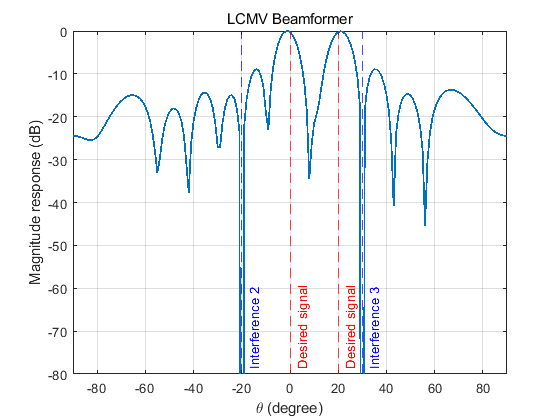

In [8]:

D_plot = steering_vector(theta_plot);     % M×Ntheta
P_LS_0 = w_opt'*D_plot;
BP_LS_0 = 20*log10( ...
    abs(P_LS_0)/max(abs(P_LS_0)) + eps);
figure;
h_bp = plot(theta_plot, BP_LS_0, 'LineWidth', 1.3);
grid on;
xlim([-90 90]);
ylim([-80 0]);
hold on;
h_desired1 = xline(theta(1), 'r--', 'Desired signal', ...
    'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
h_desired2 = xline(theta(2), 'r--', 'Desired signal', ...
    'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
h_interf = gobjects(1, numel(theta)-1);
for ii = 3:numel(theta)
    h_interf(ii-1) = xline(theta(ii), 'b--', ...
        sprintf('Interference %d', ii-1), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end

xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title('LCMV Beamformer');